In [ ]:
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from typing import TypedDict, Literal
from typing_extensions import Annotated
# reducer
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
import os
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()
project = os.getenv('GOOGLE_CLOUD_PROJECT')


# model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    vertexai = True,
    project = project
)

/opt/anaconda3/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [2]:
from langgraph.graph import MessagesState

In [10]:
def node_1(state: MessagesState):
    role = [SystemMessage(content="You are ask_llm in the field of AI. Please answer the question based on the following conversation history.")]
    
    response = llm.invoke(role + state["messages"])
    return {"messages": response}


In [12]:
graph = StateGraph(MessagesState)

In [13]:
graph.add_node("ask_llm", node_1)

In [14]:
graph.add_edge(START, "ask_llm")
graph.add_edge("ask_llm", END)     

In [15]:
state_graph = graph.compile()

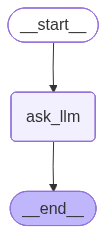

In [16]:
state_graph

In [17]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is Langgraph?")]})

In [18]:
for message in response['messages']:
    print(message.content)

What is Langgraph?
LangGraph is a **Python library for building applications that involve multiple steps, loops, and conditional logic, all orchestrated by a Large Language Model (LLM)**.

Think of it as a framework for creating **stateful, multi-agent workflows** or **complex LLM-powered agents**.

Here's a breakdown of what that means and why it's useful:

**Key Concepts:**

*   **Graphs:** LangGraph represents your application as a graph. Nodes in the graph are typically LLM calls, tool usage, or other computational steps. Edges represent the flow of control between these nodes.
*   **State:** The graph has a defined "state" that is updated as the execution progresses. This state can contain information like the LLM's response, the output of a tool, user input, or any other relevant data.
*   **Runnables:** LangGraph leverages LangChain Expression Language (LCEL) runnables. This means you can easily compose LLMs, prompts, output parsers, and tools into the nodes of your graph.
*   *